In [10]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from tqdm import tqdm

In [11]:
# Create the environment
def create_env(slippery : bool = False):
  env = gym.make("FrozenLake-v1", map_name="8x8", is_slippery=slippery)
  return env

In [12]:
#Function used to set custom reward
def custom_reward(env: gym.Env, step_penalty: float = 0.0, hole_penalty: float = 0.0, goal_reward: float = 1.0):
    desc = np.asarray(env.unwrapped.desc, dtype=str).flatten()  # shape: (n_states,)
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    # Build R[s, a, s'] based on the *destination* tile type
    reward = np.zeros((n_states, n_actions, n_states), dtype=float)
    for s in range(n_states):
        for a in range(n_actions):
            for _, s_next, _, _ in env.unwrapped.P[s][a]:
                tile = desc[s_next]
                if tile == "G":
                    reward[s, a, s_next] = goal_reward
                elif tile == "H":
                    reward[s, a, s_next] = hole_penalty
                else:
                    reward[s, a, s_next] = step_penalty  # S or F tiles

    # Recompute transition matrix cleanly
    transition = np.zeros((n_states, n_actions, n_states), dtype=float)
    for s in range(n_states):
        for a in range(n_actions):
            for prob, s_next, _, _ in env.unwrapped.P[s][a]:
                transition[s, a, s_next] += prob

    expected_reward = np.sum(transition * reward, axis=2)
    return transition, reward, expected_reward

In [13]:
def get_q_val(transition, expected_reward, values, gamma):
  return expected_reward + gamma * np.einsum("ijk,k->ij", transition, values)

In [14]:
def policy_eval_montecarlo(env, policy, gamma, episodes=3000, max_steps=500, epsilon=0.3):
    n_states = env.observation_space.n
    values = np.zeros(n_states)
    returns = {s: [] for s in range(n_states)}
    episode_rewards = []
    episode_lengths = []

    desc = np.asarray(env.unwrapped.desc, dtype=str).flatten()  #Extract all the types of state
    valid_starts = [s for s in range(n_states) if desc[s] in ("S", "F")]  #Valid Start are only S and F, can't start at H or G.

    for episode in range(episodes):
        env.reset()
        start_state = np.random.choice(valid_starts)
        env.unwrapped.s = start_state
        state = start_state
        trajectory = []

        # Eps linearly decreases from epsilon to 0
        eps = epsilon * (1 - episode / episodes)  # E - Greedy initially and then greedy/deterministic by end

        for step in range(max_steps):
            if np.random.random() < eps:
                action = env.action_space.sample()  # explore
            else:
                action = policy[state]              # exploit

            next_state, r, terminated, truncated, _ = env.step(action)
            trajectory.append((state, r))
            if terminated or truncated:
                break
            state = next_state

        episode_rewards.append(sum(r for _, r in trajectory))
        episode_lengths.append(len(trajectory))

        visited_in_episode = set()
        G = 0.0
        for state_t, r_t in reversed(trajectory):
            G = r_t + gamma * G
            if state_t not in visited_in_episode:
                visited_in_episode.add(state_t)
                returns[state_t].append(G)
                values[state_t] = np.mean(returns[state_t])

    return values, np.mean(episode_rewards), np.mean(episode_lengths)

In [15]:
def policy_iteration(env, transition, reward, gamma=0.99, max_iterations=100):
    n_states = transition.shape[0]
    n_actions = env.action_space.n
    policy = np.random.randint(0, n_actions, size=n_states)

    all_avg_rewards = []
    all_avg_lengths = []

    for iteration in tqdm(range(max_iterations), desc="Policy Iteration"):
        values, avg_reward, avg_length = policy_eval_montecarlo(
            env, policy, gamma, episodes=3000, max_steps=500, epsilon = 0.0   #For now epsilon = 0.0
        )

        all_avg_rewards.append(avg_reward)
        all_avg_lengths.append(avg_length)

        q = get_q_val(transition, reward, values, gamma)
        new_policy = np.argmax(q, axis=1)

        if np.array_equal(new_policy, policy):
            return values, policy, iteration + 1, all_avg_rewards, all_avg_lengths

        policy = new_policy

    values, avg_reward, avg_length = policy_eval_montecarlo(
        env, policy, gamma, episodes=3000, max_steps=500, epsilon = 0.0  #For now epsilon = 0.0
    )
    all_avg_rewards.append(avg_reward)
    all_avg_lengths.append(avg_length)

    return values, policy, max_iterations, all_avg_rewards, all_avg_lengths

In [16]:
def plot_policy_on_frozen_lake(env, policy, title="FrozenLake policy"):
	desc = np.asarray(env.unwrapped.desc, dtype=str)
	policy_grid = np.asarray(policy).reshape(desc.shape)
	arrows = np.array(["<", "v", ">", "^"])
	colors = {
		"S": "#9be7a1",
		"F": "#dceefb",
		"H": "#3a3a3a",
		"G": "#ffd54f",
	}

	fig, ax = plt.subplots(figsize=(8, 8))
	for r in range(desc.shape[0]):
		for c in range(desc.shape[1]):
			tile = desc[r, c]
			rect = plt.Rectangle((c, desc.shape[0] - 1 - r), 1, 1, facecolor=colors[tile], edgecolor="black", linewidth=1.5)
			ax.add_patch(rect)

			if tile == "H":
				label = "H"
			elif tile == "G":
				label = "G"
			elif tile == "S":
				label = f"S{arrows[policy_grid[r, c]]}"
			else:
				label = arrows[policy_grid[r, c]]

			ax.text(c + 0.5, desc.shape[0] - 1 - r + 0.5, label, ha="center", va="center", fontsize=16, fontweight="bold", color="black")

	ax.set_xlim(0, desc.shape[1])
	ax.set_ylim(0, desc.shape[0])
	ax.set_xticks(np.arange(desc.shape[1] + 1))
	ax.set_yticks(np.arange(desc.shape[0] + 1))
	ax.grid(True, color="black", linewidth=1.0)
	ax.set_xticklabels([])
	ax.set_yticklabels([])
	ax.set_aspect("equal")
	ax.set_title(title)
	plt.tight_layout()
	plt.show()

In [17]:
def plot_training_stats(all_avg_rewards, all_avg_lengths):
    iterations = range(1, len(all_avg_rewards) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(iterations, all_avg_rewards, color='blue')
    ax1.set_xlabel("Policy Iteration")
    ax1.set_ylabel("Average Reward per Episode")
    ax1.set_title("Avg Reward vs Iteration")

    ax2.plot(iterations, all_avg_lengths, color='orange')
    ax2.set_xlabel("Policy Iteration")
    ax2.set_ylabel("Average Episode Length")
    ax2.set_title("Avg Episode Length vs Iteration")
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.show()

Policy Iteration: 100%|██████████| 100/100 [03:00<00:00,  1.80s/it]


Converged in 100 iterations
[2 1 1 1 1 1 1 1 1 2 2 2 2 2 1 1 1 1 1 0 1 2 1 1 2 2 2 2 1 0 2 1 3 2 3 0 2
 1 2 1 3 0 0 2 2 1 0 1 1 0 2 3 0 1 0 1 2 2 3 0 2 2 2 0]


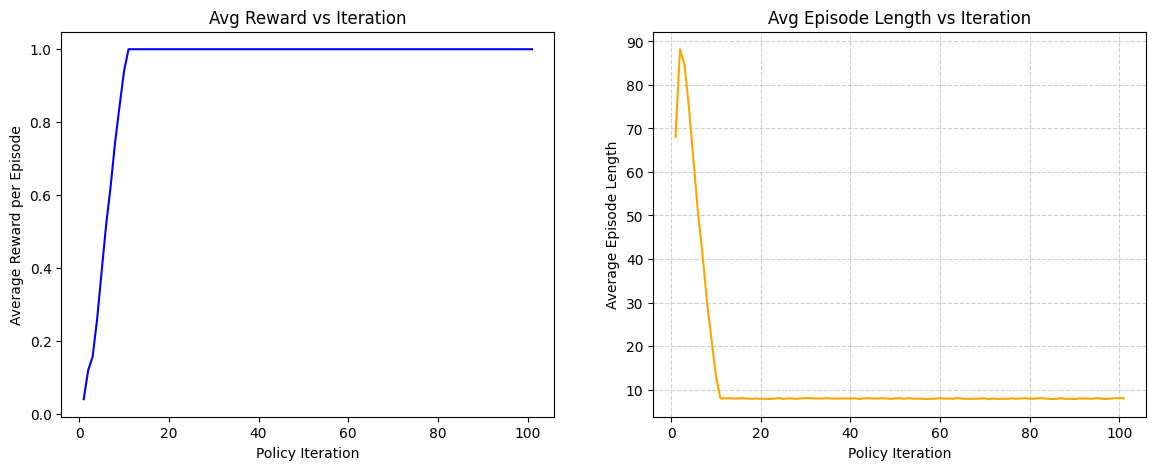

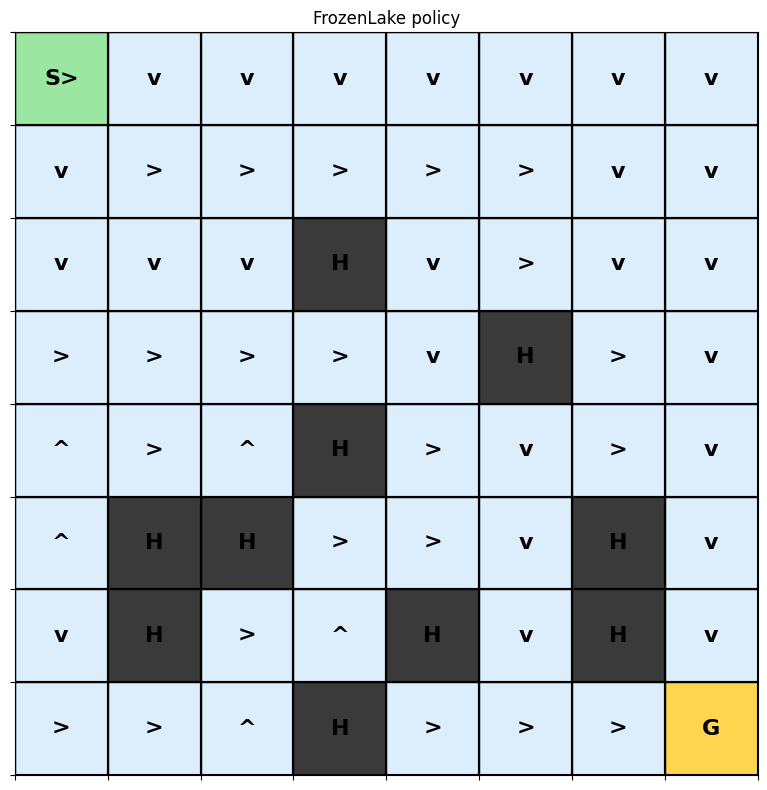

In [18]:
def main():
    env = create_env(slippery=False)
    transition, reward, expected_reward = custom_reward(
        env,
        step_penalty=-1.0,
        hole_penalty=-10.0,
        goal_reward=100.0
    )
    gamma = 0.99

    _, policy, num_iters, all_avg_rewards, all_avg_lengths = policy_iteration(
    env, transition, expected_reward, gamma)

    print(f"Converged in {num_iters} iterations")
    print(policy)

    plot_training_stats(all_avg_rewards, all_avg_lengths)
    plot_policy_on_frozen_lake(env, policy)
if __name__ == "__main__":
  main()